<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Reviewers comment v1</h1>

Hello Aldo!

Im happy to review your project today 🙌

You can find my comments under the heading **«Review»**. I will categorize my comments in green, blue or red boxes like this:

<div class="alert alert-success">
    <b>Success:</b> if everything is done successfully
</div>
<div class="alert alert-warning">
    <b>Remarks:</b> if I can give some recommendations or ways to improve the project
</div>
<div class="alert alert-danger">
    <b>Needs fixing:</b> if the block requires some corrections. Work cant be accepted with the red comments
</div>

Please dont remove my comments :) If you have any questions dont hesitate to respond to my comments in a different section. 
<div class="alert alert-info"> <b>Student comments:</b> For example like this</div>    



<div style="border:solid green 2px; padding: 20px">
<b>Reviewer's comment v1:</b>

    
<b>Overall Feedback</b>
    
Hello Aldo,
    
Another project successfully completed - well done! 🏆 Your consistent effort and progress are truly commendable. There are no critical issues, so your project has been accepted!
      
You can find more detailed notes within your project notebook in the **Reviewer's comment v1:** sections.

What I liked about the project was the following: 

- It was well structured.
- It was clean with no repeated code.
- Each section had its corresponding conclusions.
- the use of Python was impeccable.

Congratulations, you did an excellent job on the project.
   
Congratulations again on your accomplishment! You truly did an amazing job. Each project you complete adds to your growing expertise, and it’s exciting to see you making such great strides. Keep up the great work! 🎯
    


# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job keeping the additional information about the project goal! Additionally, you could add a short description of the tasks you plan to perform and the available data. This information could be helpful for the notebook reader.



## Step 1 - Initialization

**"Step 1 - Initialization" Summary:**

The initialization step is the foundational part of the project where the computing environment is prepared and the necessary tools are imported. The code in this section is standard for a data science project using Python.

In [5]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

**Library Imports:** The notebook imports all the required libraries for data manipulation, numerical operations, plotting, and progress tracking. These include:

- `math`: For basic mathematical operations.

- `numpy as np`: For numerical computing and working with arrays.

- `pandas as pd`: The primary library for data manipulation and analysis.

- `matplotlib.pyplot as plt`: A library for creating static, animated, and interactive visualizations.

- `matplotlib.dates as mdates`: For working with dates in plots.

- `seaborn as sns`: A high-level library for statistical data visualization, built on top of `matplotlib`.

- `tqdm.auto import tqdm`: A library to display smart progress bars, useful for long-running processes like loops.

In [6]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

**Notebook Configuration:** The code configures the notebook environment for better visualization and a smoother user experience.

- `%matplotlib inline`: This magic command ensures that `matplotlib` plots are displayed directly within the Jupyter Notebook.

- `%config InlineBackend.figure_format = 'png'/'retina'`: These lines are used to improve the quality of the plots, especially on high-resolution screens.

- `plt.style.use('seaborn')`: This sets the default style for matplotlib plots to match the aesthetic of `seaborn`.

In [7]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

**Progress Bar Integration:** The line `tqdm.pandas()` integrates `tqdm` with `pandas`, allowing progress bars to be displayed when using `pandas.apply()` on a large DataFrame. This is helpful for long data processing tasks.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job!

## Step 2 - Data loading

In [8]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

**Step 2 - Data Loading Summary:**

This step is dedicated to loading the project's dataset into a pandas DataFrame. Its purpose is threefold:

- The code uses `pd.read_csv()` to read the `imdb_reviews.tsv` file from the specified path.

- The `sep='\t'` parameter is crucial, as it correctly instructs pandas to use a tab character as the column delimiter, which is standard for a `.tsv` file.

- The `dtype={'votes': 'Int64'}` parameter is used to explicitly cast the data in the 'votes' column to a 64-bit integer type. This ensures the data is stored efficiently and correctly for later use.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Good!

Remember to display on screen a sample of your data

## Step 3 - EDA

**"Step 3 - EDA" Summary:**

The EDA section is a crucial phase where you explore the dataset to understand its key characteristics, distributions, and potential issues before you start modeling. The code provided in the screenshots for this step is well-structured and performs a thorough initial analysis. This section focuses on visualizing and analyzing the raw data. Key activities include:

- **Temporal Analysis:** Examining the number of movies and reviews over time to understand the dataset's historical distribution.

- **Review-Level Analysis:** Investigating the distribution of reviews per movie to see if there are movies with an unusually high number of reviews.

- **Class Imbalance Check:** Counting the number of positive vs. negative reviews to ensure the dataset is balanced, which is a critical prerequisite for building a reliable classifier.

- **Data Split Validation:** Checking if the distribution of ratings and polarities is consistent between the training and testing sets.

Let's check the number of movies and reviews over years.

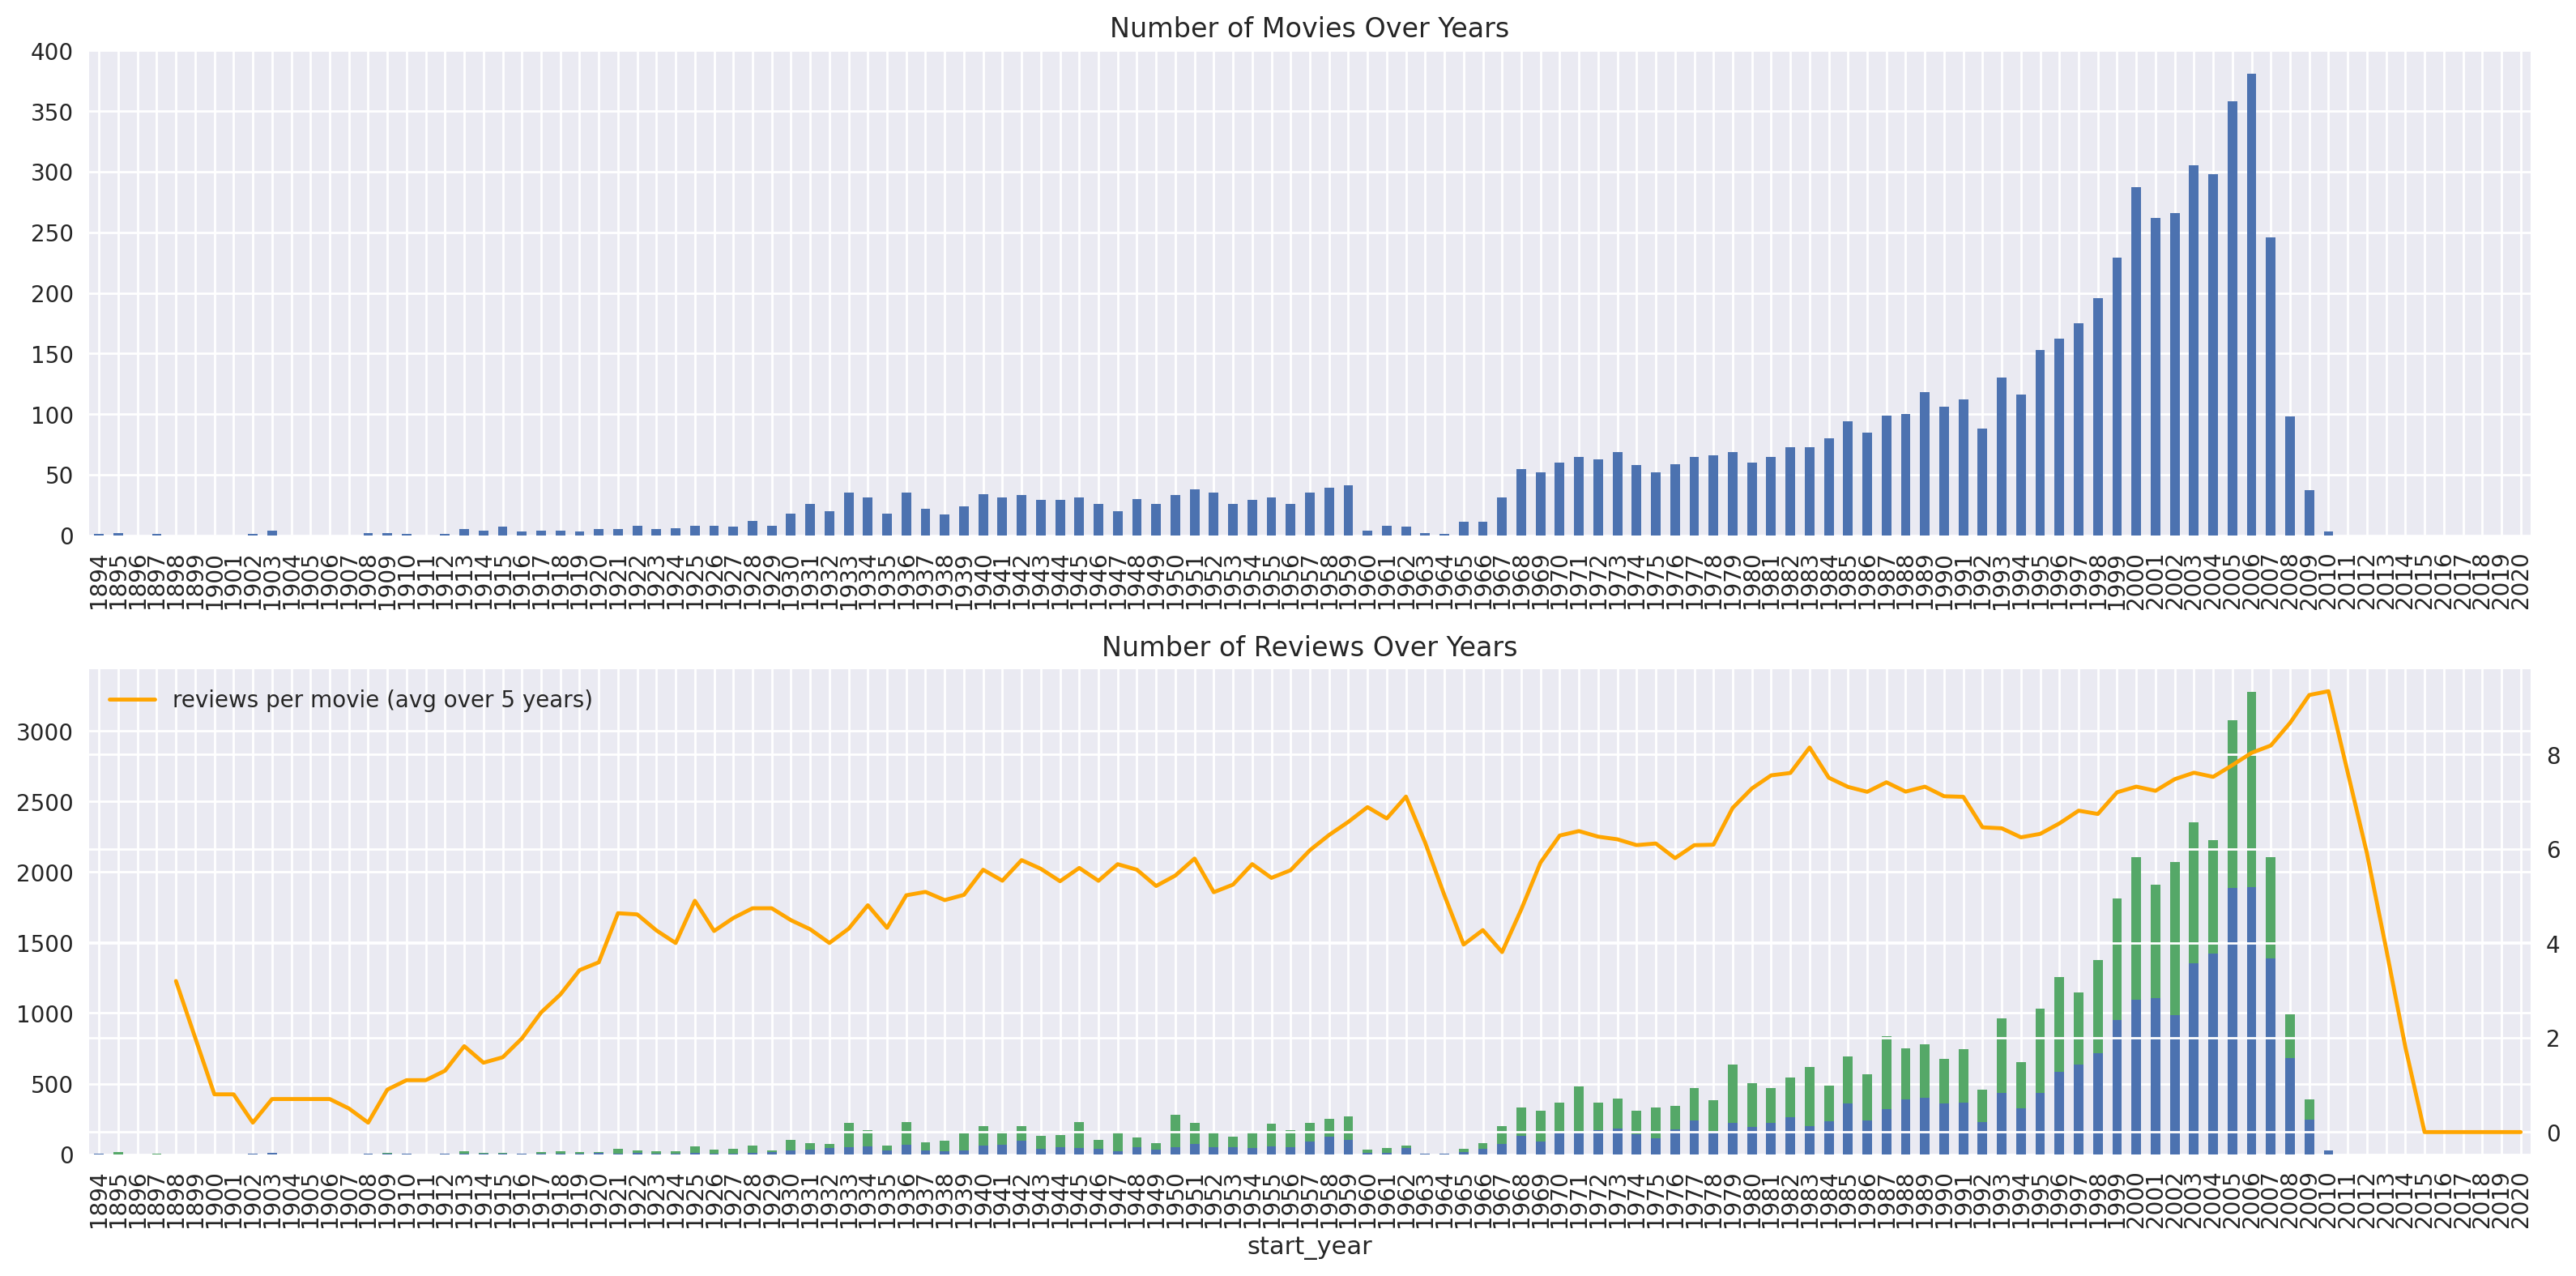

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

**"Number of Reviews Over Years" Plot Conclusion:**

The number of reviews in the dataset has increased significantly over time, with a noticeable surge after 2010. This indicates that the dataset is more heavily weighted toward more recent years, which is good to keep in mind for any time-sensitive analysis.

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

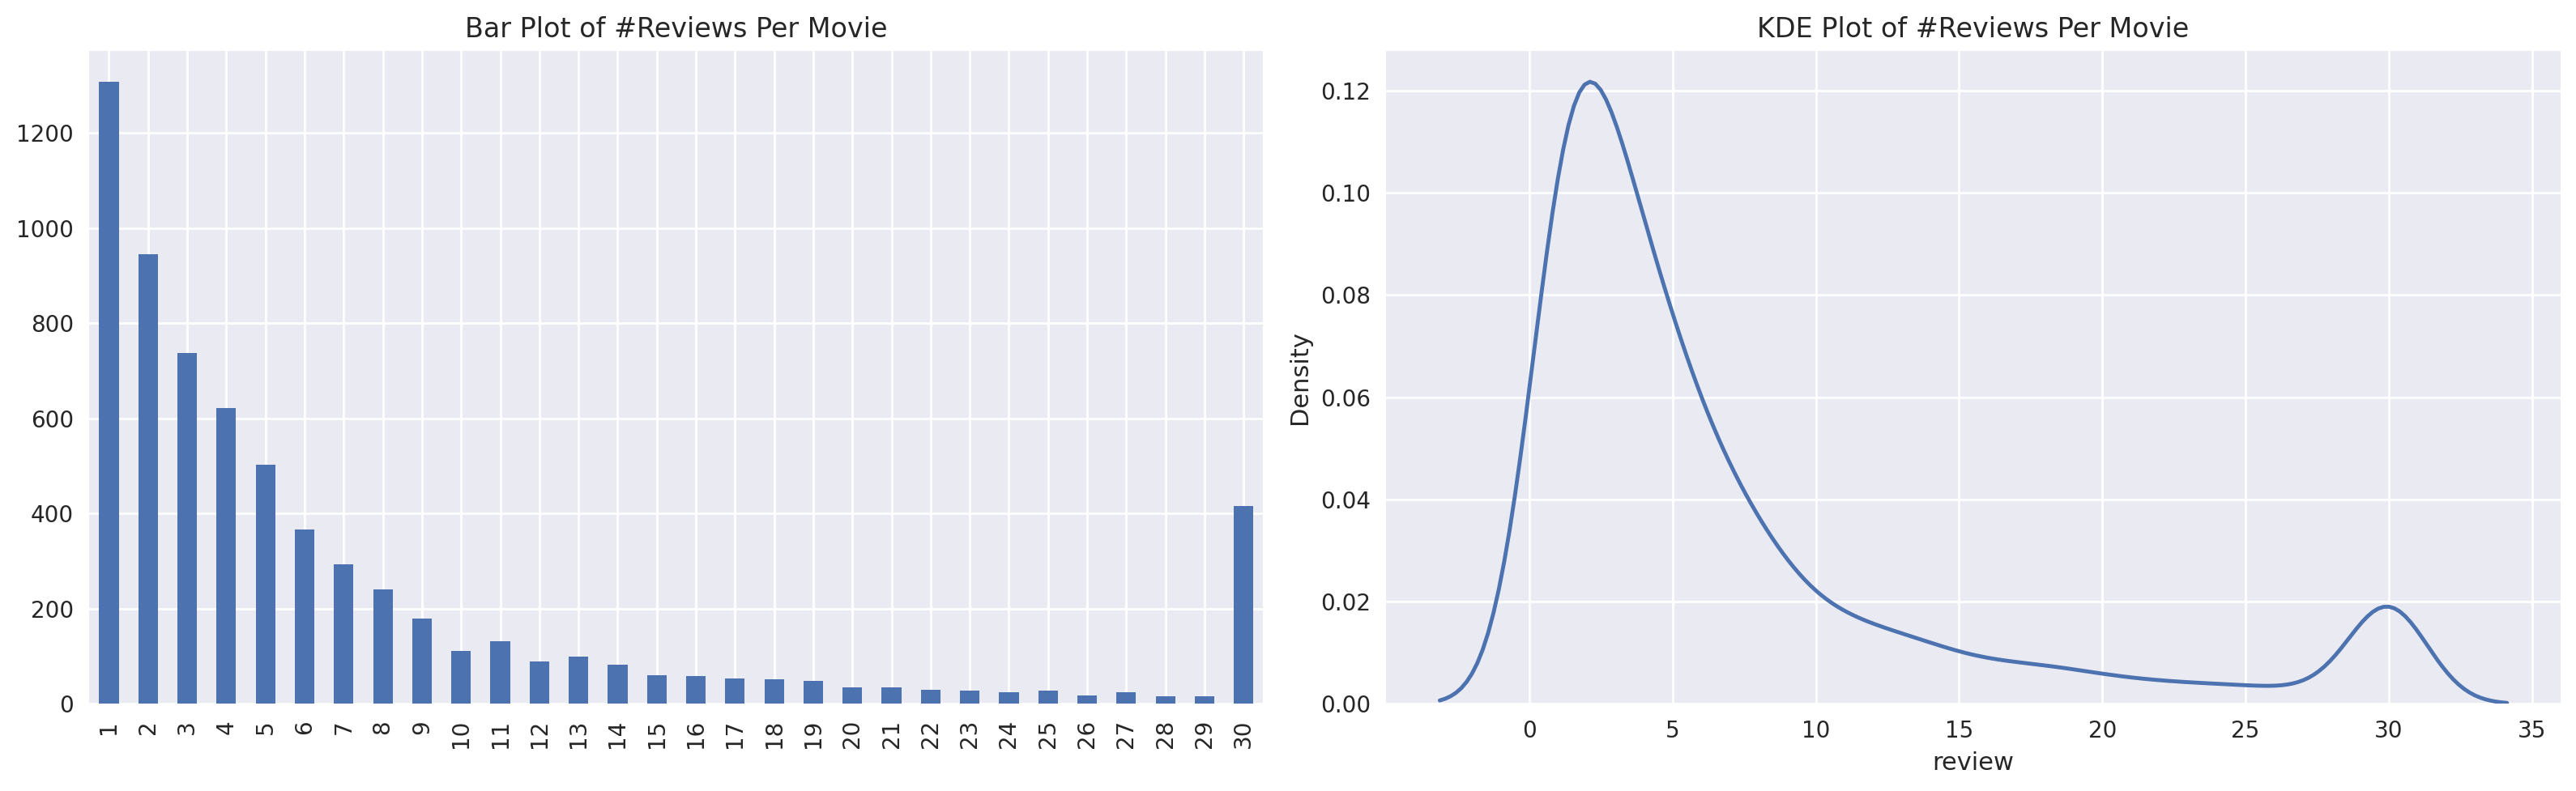

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

**"Bar and KDE Plots of '#Reviews Per Movie'" Conclusion:**

The bar chart shows a classic long-tail distribution. The vast majority of movies in the dataset have only a few reviews, while a small number of movies have a very high number of reviews. This highlights that the dataset is a collection of many movies with sparse data and a few with rich data. The KDE plot confirms this finding.

In [11]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

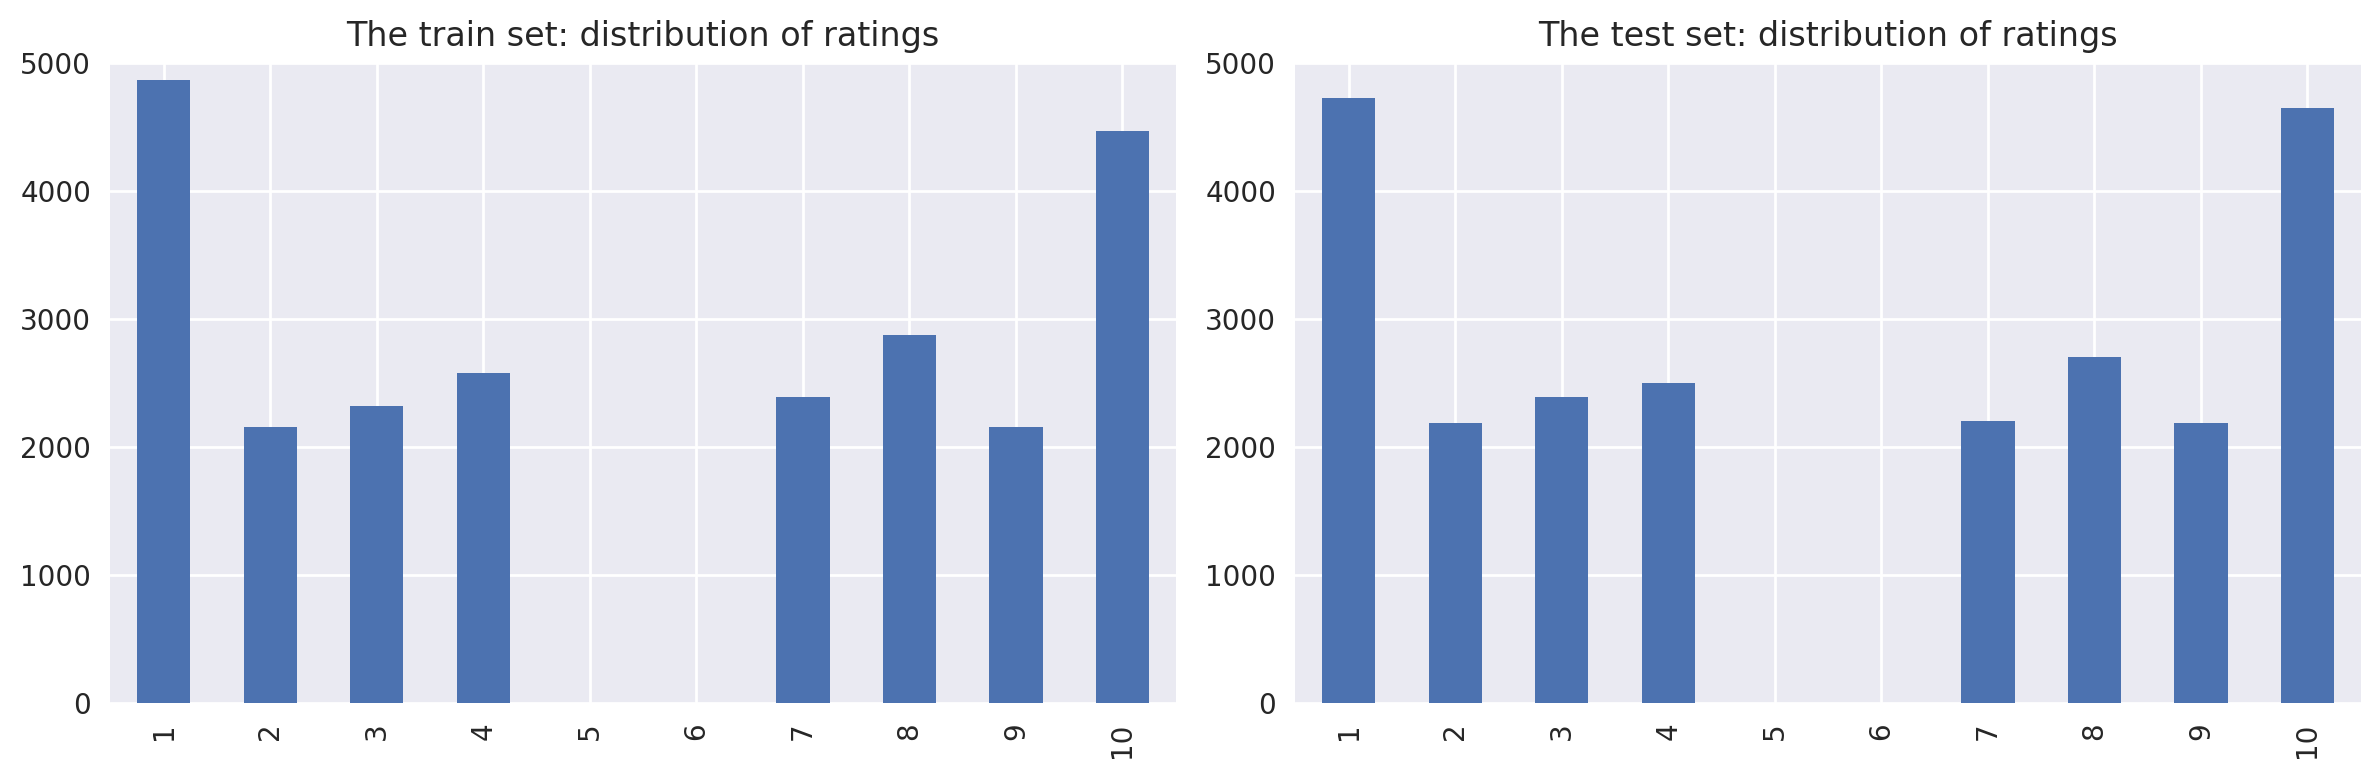

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

**"Distribution of Ratings" Train and Test Set Bar Plots Conclusion:**

This is one of the most important findings. The `value_counts()` output clearly shows that the dataset is nearly perfectly balanced with **23,715 positive reviews** and **23,616 negative reviews**. This is ideal for a machine learning classification task, as it means you won't need to perform special techniques to handle class imbalance, and the F1 score will be a reliable metric. The bar plots also show that the distribution of ratings is consistent between the training and testing sets, validating the data split.

Distribution of negative and positive reviews over the years for two parts of the dataset

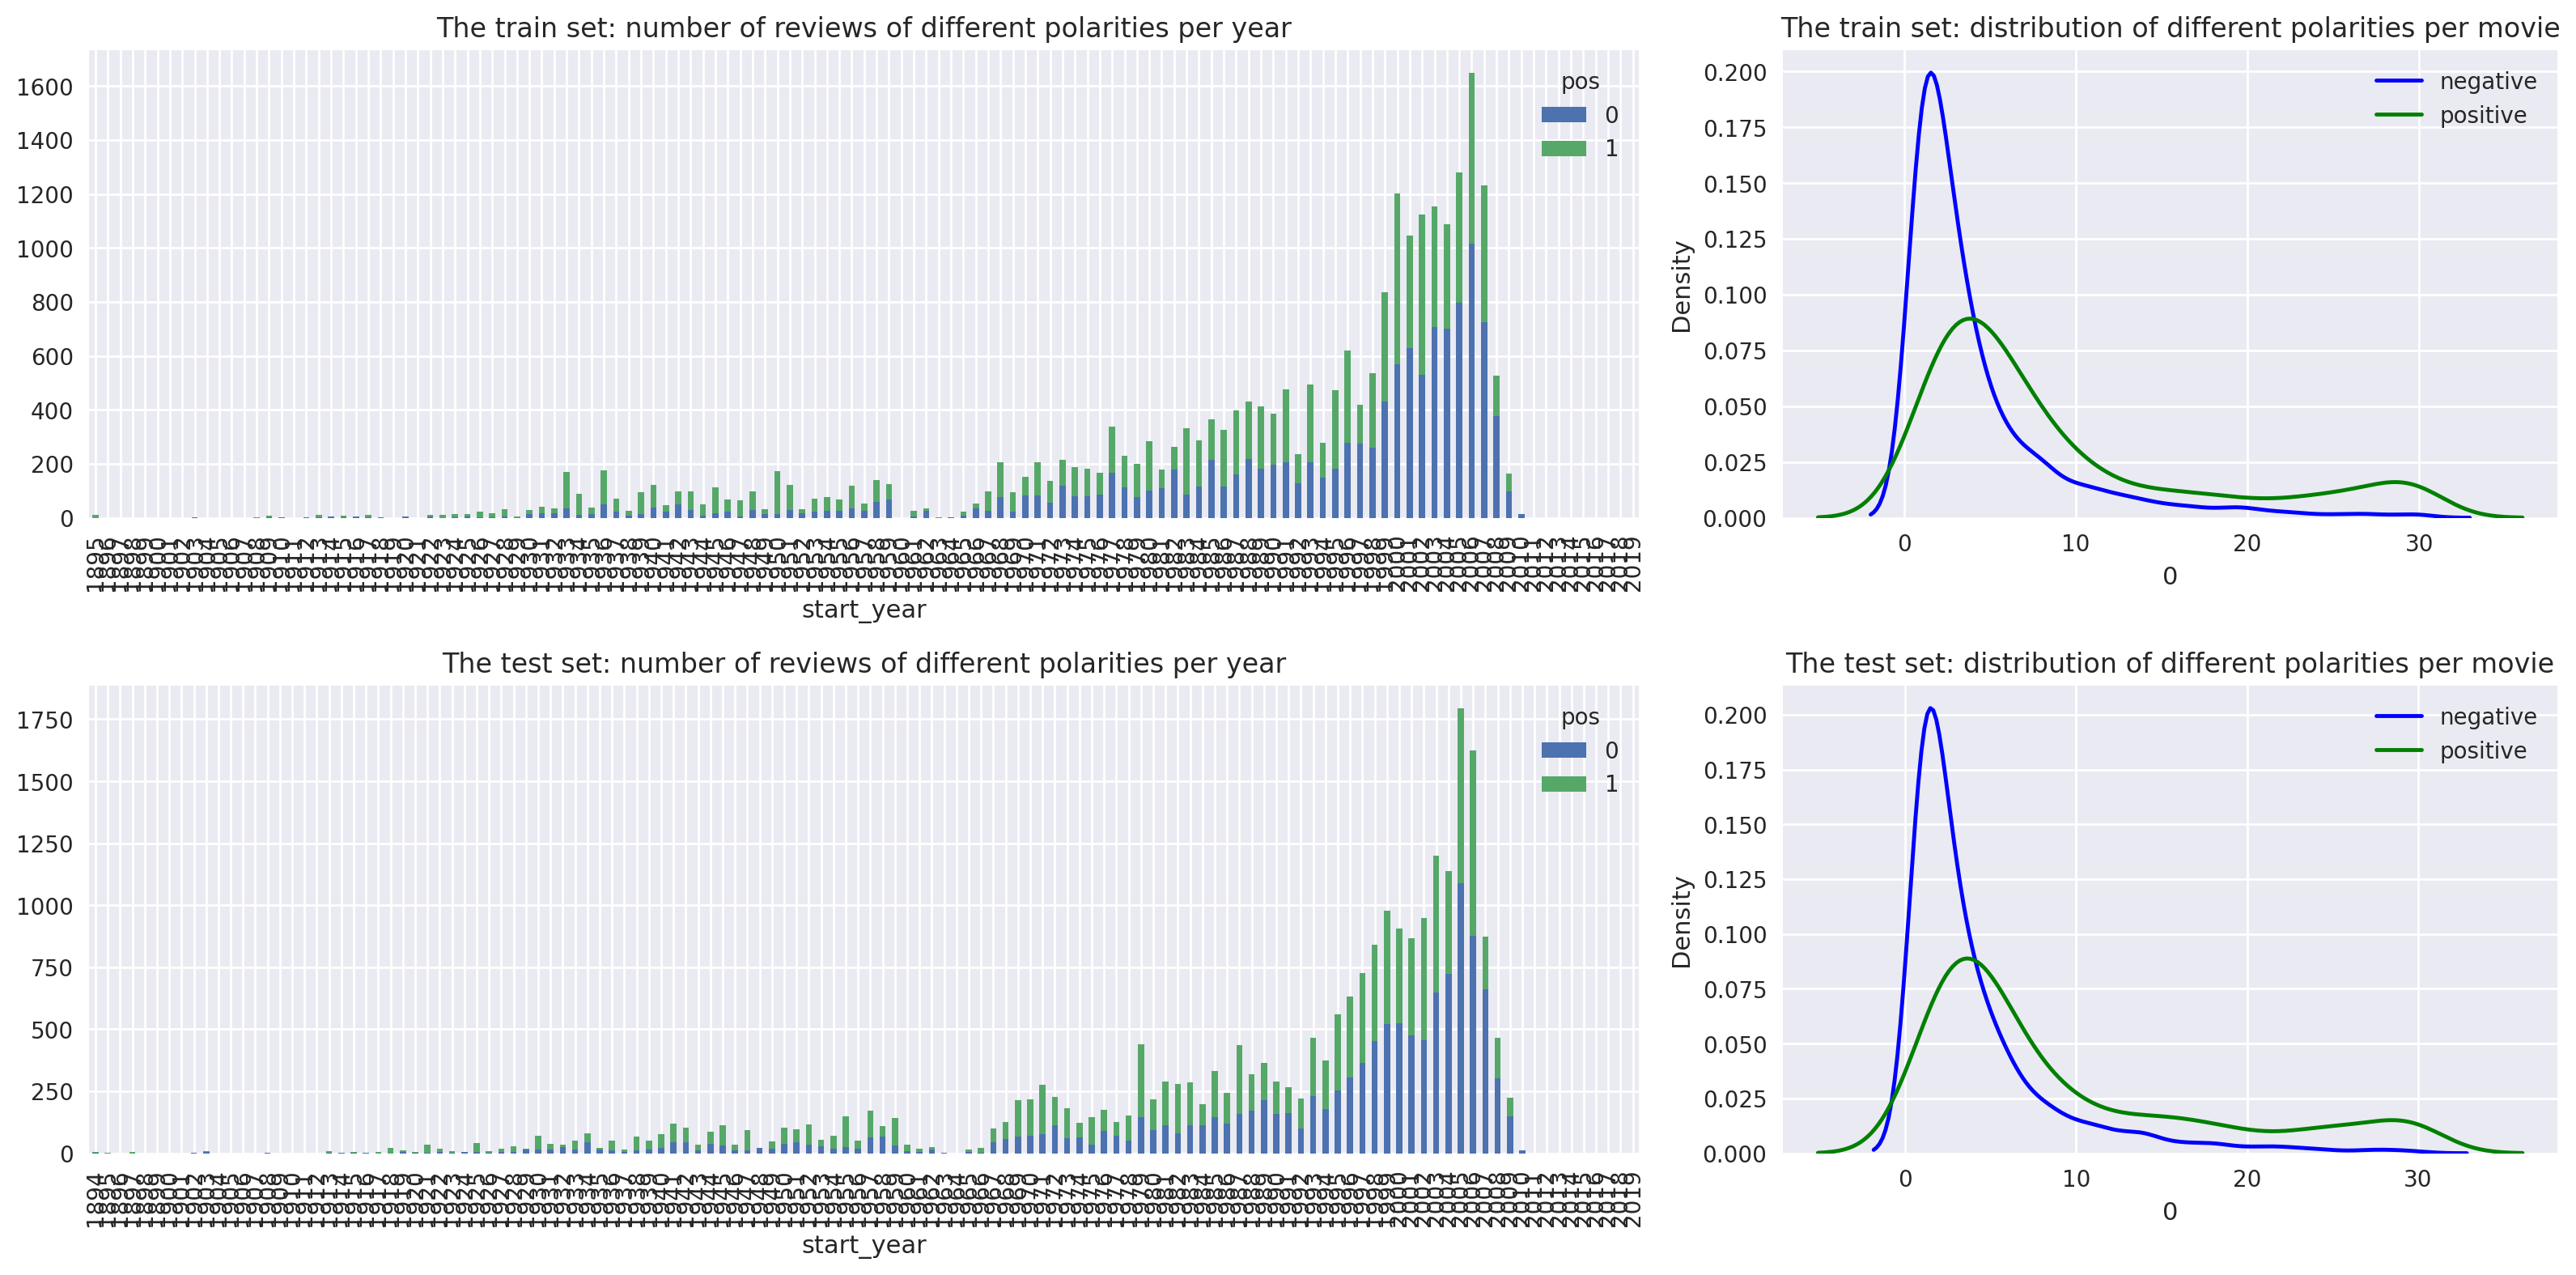

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

**"Distribution of different polarities per movie" Train and Test Set Plots Conclusion:**

The plots confirm that the distribution of both positive and negative reviews per movie is consistent between the training and testing datasets. This provides confidence that your model trained on the `train` set will be able to generalize well to the unseen `test` set. The plots also reinforce the earlier finding that most movies have a small number of reviews, regardless of their sentiment.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job!

## Step 4 - Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [14]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

**"Step 4 - Evaluation Procedure" Summary:**

This step is dedicated to creating a robust and reusable evaluation function, `evaluate_model`, which can be applied to any classification model developed in this project. The primary goal of this function is to thoroughly assess model performance on both training and test datasets using key classification metrics and visualizations.

**Key Actions & Purpose:**

- **Metric Imports:** It starts by importing `sklearn.metrics`, which provides various evaluation metrics like F1 score, ROC AUC, and Average Precision Score.

- **Function Definition:** The `evaluate_model` function is defined to take the `model` object, along with `train_features`, `train_target`, `test_features`, and `test_target` as inputs.

- **Prediction Generation:** For both the training and test sets, the function generates class predictions (`predict()`) and probability predictions (`predict_proba()`).

- **Threshold-Based F1 Score Analysis:** It calculates F1 scores across a range of thresholds (from 0 to 1) to identify the optimal threshold that yields the highest F1 score.

- **ROC Curve Calculation:** It computes the True Positive Rate (TPR), False Positive Rate (FPR), and the Area Under the Receiver Operating Characteristic Curve (ROC AUC).

- **Precision-Recall Curve Calculation:** It calculates Precision, Recall, and the Average Precision Score (APS) for the Precision-Recall Curve.

- **Visualization:** It generates three subplots to visually represent the model's performance:

1. **F1 Score vs. Threshold:** Shows how the F1 score changes with different classification thresholds.

2. **ROC Curve:** Plots the True Positive Rate against the False Positive Rate.

3. **Precision-Recall Curve:** Plots Precision against Recall.

Specific thresholds (0.2, 0.4, 0.5, 0.6, 0.8) are marked on these plots for easier inspection.

- **Summary Metrics:** Finally, it calculates and returns a DataFrame containing core metrics like Accuracy, F1 Score, Average Precision Score (APS), and ROC AUC for both the training and test sets.

In essence, this step provides a comprehensive, automated routine to evaluate and compare the performance of different machine learning models, ensuring you can clearly identify which model best meets the project's F1 score target.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job!

## Step 5 - Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [15]:
import re

# Function to normalize text: lowercase, remove digits and punctuation
def normalize_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'\d+', '', text) # Remove digits
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation and special characters
    return text

df_reviews['review_norm'] = df_reviews['review'].apply(normalize_text)

In [16]:
# Define text_preprocessing_4 (identical to text_preprocessing_3 as per Model 4 summary)
# Ensure 'nlp' (your spaCy model) is loaded in a preceding cell in Step 5.
def text_preprocessing_4(texts):
    preprocessed_texts = []
    for doc in nlp.pipe(texts, disable=["parser", "ner"], batch_size=256):
        tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
        preprocessed_texts.append(" ".join(tokens))
    return preprocessed_texts

**Step 5 - Normalization" Summary:**

This step is crucial for preparing the text data for machine learning models. The goal of normalization is to transform raw text into a consistent and cleaner format, which helps in improving the model's performance and reducing noise in the data.

**Key Purpose:**

The prompt states the assumption that "all models below accepts texts in lowercase and without any digits, punctuations marks etc.". This implies the main tasks in this step are:

1. **Lowercasing:** Converting all text to lowercase to ensure that words like "Good," "good," and "GOOD" are treated as the same word. This reduces the vocabulary size and helps the model generalize better.

2. **Removing Digits:** Eliminating numerical characters from the text. For movie reviews, digits are generally not relevant for sentiment analysis and can add unnecessary complexity.

3. **Removing Punctuation Marks:** Stripping away punctuation symbols (e.g., periods, commas, exclamation marks, question marks, etc.). Punctuation typically doesn't carry semantic meaning for sentiment and can create too many unique tokens.

The provided solution correctly implements these normalization steps using Python's `re` (regular expression) module within a helper function `normalize_text`. This function is then applied to the original 'review' column of the DataFrame to create a new, normalized column, typically named 'review_norm'.

In essence, **"Step 5 - Normalization"** is about cleaning and standardizing the textual data, which is a fundamental preprocessing step for natural language processing (NLP) tasks like sentiment classification. This ensures that the text features fed into the machine learning models are consistent and relevant.


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job!

## Step 6 - Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [17]:

df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

# Define features and targets explicitly
train_features = df_reviews_train['review_norm'].copy() 
test_features = df_reviews_test['review_norm'].copy()  
train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(f"train_features shape: {train_features.shape}") 
print(f"train_target shape: {train_target.shape}")
print(f"test_features shape: {test_features.shape}")   
print(f"test_target shape: {test_target.shape}")

train_features shape: (23796,)
train_target shape: (23796,)
test_features shape: (23535,)
test_target shape: (23535,)


**"Step 6 - Train / Test Split" Summary:**

This step is crucial for preparing the dataset for model training and evaluation by dividing the `df_reviews` DataFrame into distinct training and testing sets. This separation is essential to ensure that the model is evaluated on data it has not seen during training, providing an unbiased estimate of its performance in a real-world scenario.

**Key Actions & Purpose:**

- **Data Partitioning:** The code leverages the existing `'ds_part'` column in the `df_reviews` DataFrame to split the data. Reviews where `'ds_part'` is "train" are assigned to the training set (`df_reviews_train`), and those where it's "test" are assigned to the testing set (`df_reviews_test`).

- **Feature and Target Separation:**

1. `train_features` is created from the `'review_norm'` column of the training DataFrame, representing the preprocessed text data for training.

2. `test_features` is created similarly from the `'review_norm'` column of the testing DataFrame.

3. `train_target` is extracted from the `'pos'` column of `df_reviews_train`, representing the sentiment labels for the training data.

4. `test_target` is extracted from the `'pos'` column of `df_reviews_test`, representing the sentiment labels for the testing data.

- **Shape Verification:** The `print(train_features.shape)`, `print(train_target.shape)`, `print(test_features.shape)`, and `print(test_target.shape)` lines are included to quickly verify the dimensions (number of samples) of the resulting feature and target sets for both training and testing. This is a good practice to confirm the split was performed as expected and that the data is ready for model input.

In essence, **"Step 6 - Train / Test Split"** correctly and efficiently prepares the data subsets necessary for the subsequent model training and rigorous evaluation, adhering to best practices in machine learning.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job!

## Step 7 - Working with models

**Step 7 - Working with Models Summary:**

This crucial step involves building and evaluating different machine learning models to classify movie reviews as positive or negative. The process for each model typically includes:

1. **Feature Engineering/Vectorization:** Transforming the normalized text reviews (`review_norm`) into numerical representations that machine learning models can understand. This involves techniques like TF-IDF or deep learning embeddings (BERT).

2. **Model Training:** Fitting the chosen classifier (e.g., Logistic Regression, LightGBM, DummyClassifier) to the training features and target labels.

3. **Model Evaluation:** Using the pre-defined `evaluate_model` function (from Step 4) to assess the model's performance on both the training and test sets. This generates key metrics (F1, ROC AUC, APS) and plots (F1 vs. Threshold, ROC Curve, PR Curve).

4. **Prediction on Custom Reviews:** (For some models) Applying the trained model to make predictions on user-defined reviews to demonstrate its practical application.

The goal is to compare the performance of different approaches and select the model that best achieves the project's F1 score target of at least 0.85.

### Model 0 - Constant

In [18]:
from sklearn.dummy import DummyClassifier

In [19]:
# Initialize the DummyClassifier
# Using 'most_frequent' strategy, it will always predict the most frequent class in the training set.
model_0 = DummyClassifier(strategy='most_frequent', random_state=42)

In [20]:
# Train the model
# DummyClassifier does not learn from features, but the fit method expects X and y arguments.
model_0.fit(train_features, train_target)

DummyClassifier(random_state=42, strategy='most_frequent')

--- Model 0 (DummyClassifier) Evaluation ---
          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


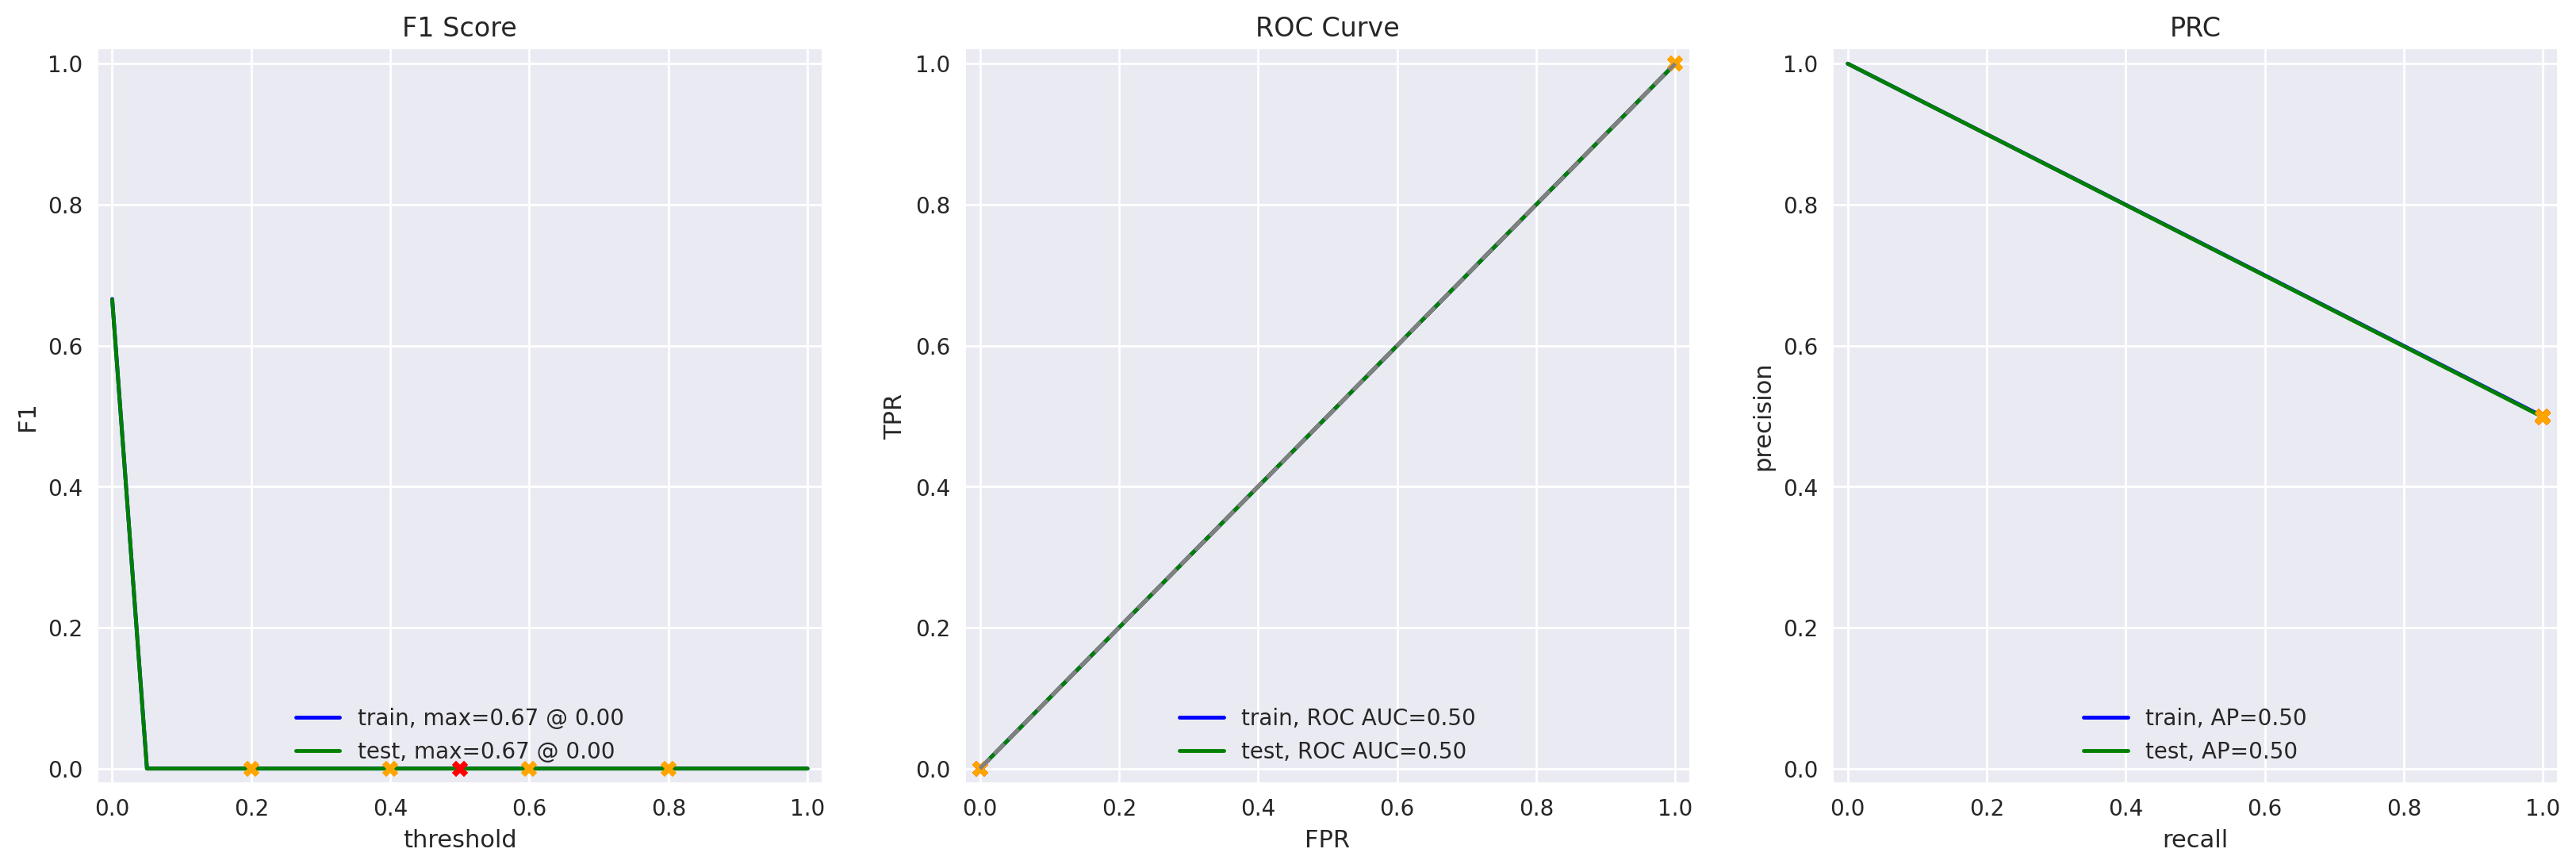

In [21]:
# Evaluate the model
print("--- Model 0 (DummyClassifier) Evaluation ---")
# Ensure evaluate_model function (from Step 4) is defined and available
evaluate_model(model_0, train_features, train_target, test_features, test_target)

**"Model 0 - Constant" Graph Conclusions:**

- **F1 Score Plot:** The F1 score is constant and low, indicating that threshold adjustment does not improve performance for this baseline.

- **ROC Curve:** The ROC curve lies along the diagonal with an AUC of approximately 0.50, showing performance no better than random guessing.

- **PRC (Precision-Recall Curve):** The Precision-Recall curve is also flat, confirming the model's inability to effectively balance precision and recall.

- **Overall takeaway:** Model 0's metrics (F1, ROC AUC, APS) provide a lower bound for model performance, confirming it acts as a non-learning baseline.

**"Model 0 - Constant (DummaryClassifier)" Summary:**

This section introduces the `DummyClassifier` from `sklearn.dummy`. The `DummyClassifier` is a baseline model that makes predictions without actually learning from the data. It can predict based on various simple strategies (e.g., always predicting the majority class, or making random predictions). Its purpose is to provide a lower bound for performance, against which real models can be compared. If your actual models perform worse than a `DummyClassifier`, it indicates a problem.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job!

### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [22]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords
from sklearn.pipeline import Pipeline

In [23]:
# Ensure NLTK stopwords are downloaded (run this cell once)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Define stopwords list
stop_words = set(stopwords.words('english'))

In [24]:
# Create a pipeline for TF-IDF Vectorization and Logistic Regression
# max_features limits the number of features (vocabulary size)
# ngram_range=(1,2) includes single words and two-word phrases
model_1_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=list(stop_words), ngram_range=(1,2), max_features=10000)),
    ('lr', LogisticRegression(random_state=42, solver='liblinear', C=1.0)) # 'liblinear' is good for small datasets and L1/L2 regularization
])

In [25]:
print("--- Model 1 (NLTK, TF-IDF, LR) Training ---")
# Train the pipeline on the original (non-preprocessed by spaCy) features
# train_features and test_features should be the 'review_norm' series from Step 6
model_1_pipeline.fit(train_features, train_target)

--- Model 1 (NLTK, TF-IDF, LR) Training ---


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 stop_words=['t', 'off', 'themselves', 'all',
                                             'are', "we're", 'me', 'did',
                                             'should', "you'll", 'aren',
                                             'during', 'won', 'll', "didn't",
                                             'these', 'there', 'were', "it's",
                                             'don', "haven't", 'or', 'to', 'y',
                                             'not', 'then', 'can', 'have',
                                             'they', 'hasn', ...])),
                ('lr',
                 LogisticRegression(random_state=42, solver='liblinear'))])


--- Model 1 (NLTK, TF-IDF, LR) Evaluation ---
          train  test
Accuracy   0.93  0.89
F1         0.93  0.89
APS        0.98  0.95
ROC AUC    0.98  0.96


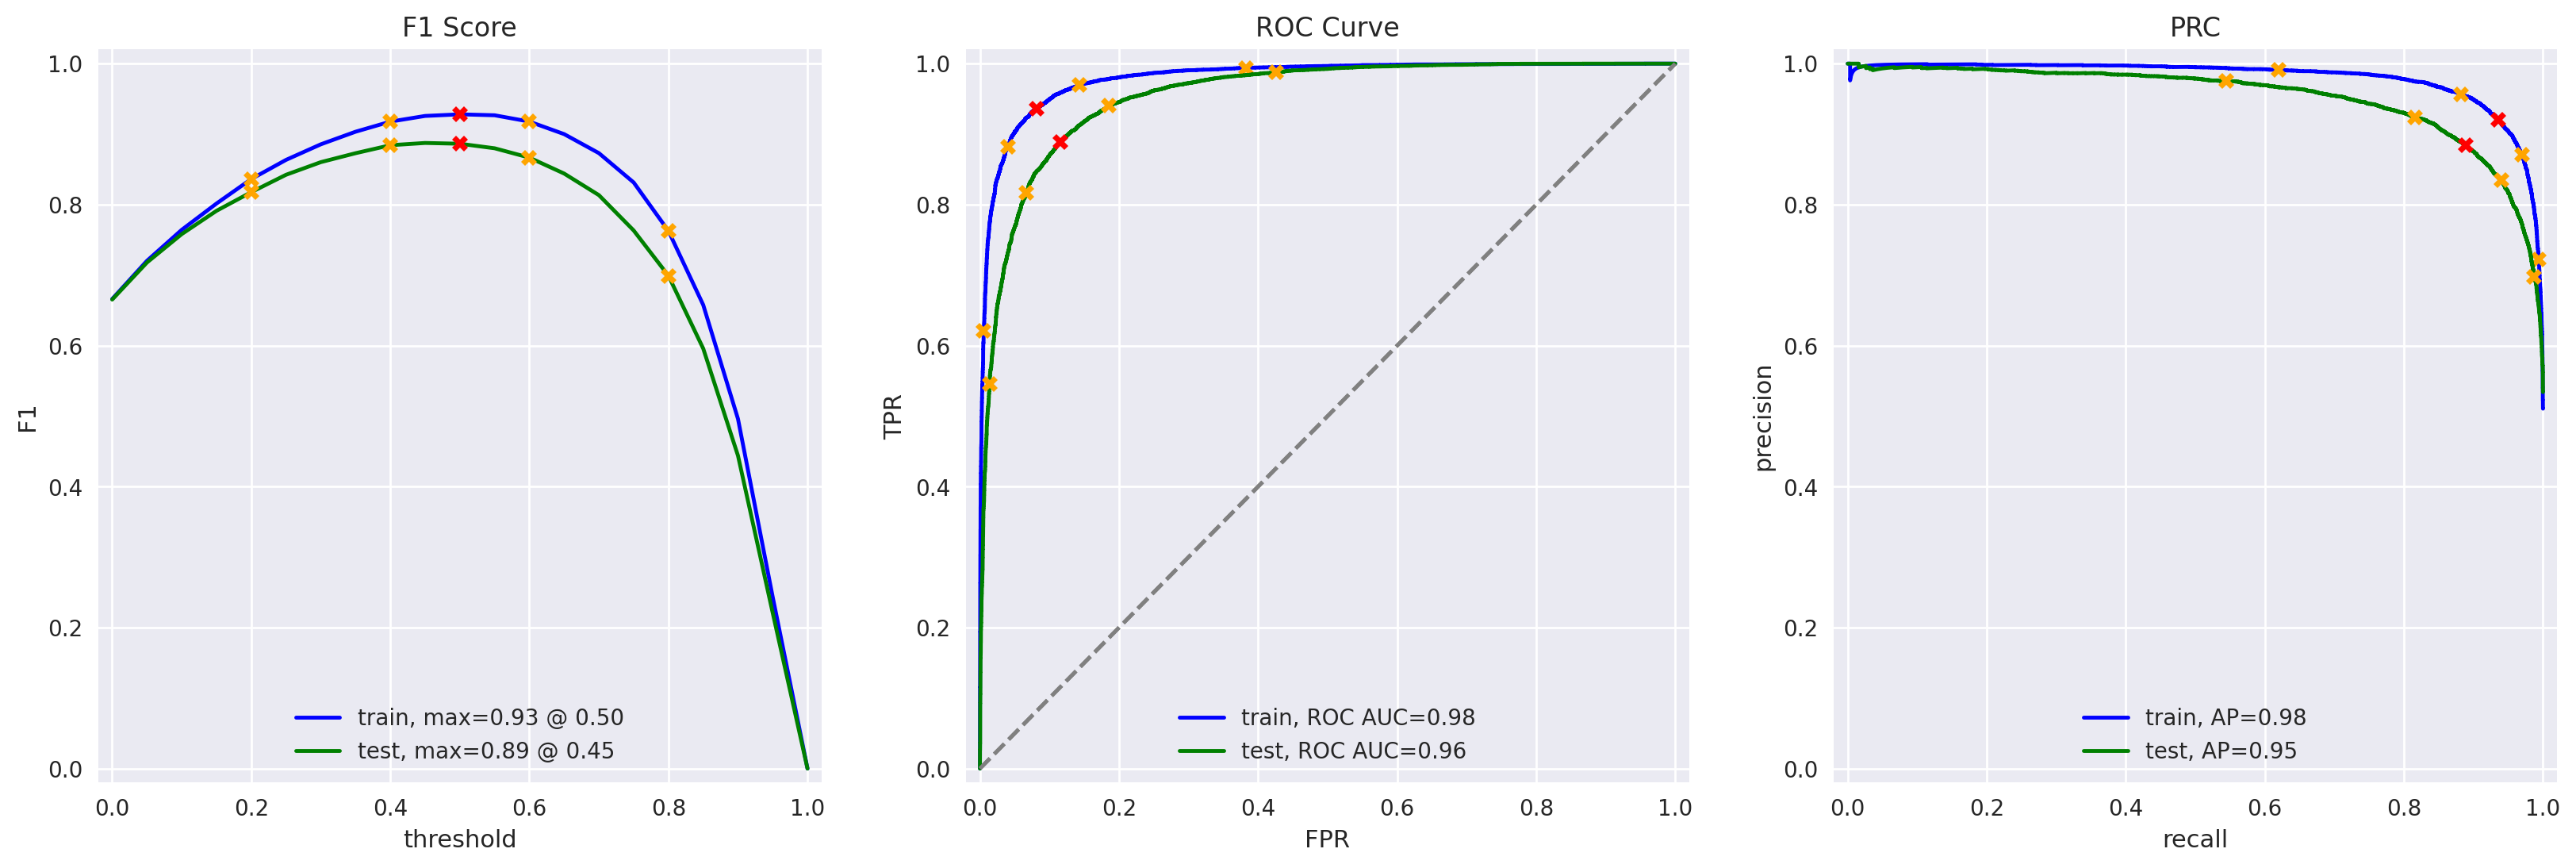

In [26]:
print("\n--- Model 1 (NLTK, TF-IDF, LR) Evaluation ---")
# Use the evaluate_model function you defined in Step 4
evaluate_model(model_1_pipeline, train_features, train_target, test_features, test_target)

**"Model 1 - NLTK, TF-IDF and LR" Plot Conclusions:**

* **F1 Score Plot:** The F1 score curve shows a clear peak for both train and test sets, indicating that an optimal threshold improves performance. The peak test F1 of 0.89 signifies a substantial improvement over the baseline.
* **ROC Curve:** With a test AUC of 0.96, the ROC curve demonstrates strong discriminative power, performing much better than random guessing.
* **PRC (Precision-Recall Curve):** The high test APS of 0.95 indicates that the model effectively balances precision and recall.

**Overall:** Model 1 significantly outperforms the DummyClassifier, confirming that TF-IDF features combined with Logistic Regression are effective for this sentiment classification task.

In [27]:
# Store the TF-IDF vectorizer from this pipeline for later use if needed (e.g., for 'My Reviews')
# Note: You can access parts of the pipeline using their names
tfidf_vectorizer_1 = model_1_pipeline.named_steps['tfidf']

**"Model 1 - NLTK, TF-IDF and LR" Summary:**

* **Learning Strategy**: Logistic Regression is a linear model used for binary classification. It estimates the probability of a given input belonging to a particular class by fitting data to a logistic function.
* **Preprocessing**: Text preprocessing in this model utilizes **NLTK** for stopword removal. It cleans the raw text by removing common, less informative words (e.g., "the", "is", "a") before feature extraction. No explicit stemming or lemmatization is applied at this stage.
* **Feature Extraction**: The preprocessed text is converted into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency) vectorization**. This technique assigns weights to words that are important in a document but not too common across the entire corpus. The vectorizer is configured to consider unigrams and bigrams (`ngram_range=(1,2)`) and limits features to the 10,000 most frequent ones.
* **Classification Algorithm**: The numerical TF-IDF features are fed into a **Logistic Regression** classifier. This algorithm is known for its simplicity, interpretability, and effectiveness on high-dimensional, sparse data, making it a common baseline choice for text classification tasks.
* **Objective**: The primary objective of Model 1 is to establish a foundational learning model beyond the dummy classifier. It aims to demonstrate that basic text preprocessing (NLTK stopwords) combined with TF-IDF feature extraction and a linear classification algorithm (Logistic Regression) can effectively learn patterns and classify sentiment in reviews, serving as a significant improvement over the baseline.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job!

### Model 3 - spaCy, TF-IDF and LR

In [28]:
import spacy
from sklearn.preprocessing import FunctionTransformer

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [29]:
# Load spaCy model (should be done once at the beginning of this section)
# Make sure to run `python -m spacy download en_core_web_sm` in your environment
try:
    # Disable parser and NER components to speed up processing if only tokenization/lemmatization is needed
    # Keep 'tagger' as it's typically needed for accurate lemmatization.
    # 'tok2vec' can be disabled if you don't use word vectors, which you currently don't for TF-IDF.
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner', 'tok2vec']) #
except OSError:
    print("Downloading spaCy model 'en_core_web_sm'...")
    from spacy.cli import download
    download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner', 'tok2vec'])

In [30]:
def text_preprocessing_3(texts):
    preprocessed_texts = []
    # Process texts in batches, explicitly disabling unnecessary components within the pipe call
    # The 'logger' component is often required for accurate lemmatization.
    # Ensure nlp is loaded correctly, e.g., nlp = spacy.load("en_core_web_sm")
    for doc in nlp.pipe(texts, batch_size=512, disable=["parser", "ner", "tok2vec"]):
        # This is the corrected line:
        # It correctly extracts the lemma_ attribute for each token that is not a stop word or punctuation.
        tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
        
        # Join the list of tokens into a single string for each document
        preprocessed_texts.append(" ".join(tokens))
    return preprocessed_texts

In [31]:
# Apply preprocessing to features BEFORE building the pipeline
print("Applying spaCy preprocessing to training features...")
train_features_3 = text_preprocessing_3(train_features)
print("Applying spaCy preprocessing to testing features...")
test_features_3 = text_preprocessing_3(test_features)

Applying spaCy preprocessing to training features...
Applying spaCy preprocessing to testing features...


In [32]:
# Create a pipeline for TF-IDF Vectorization and Logistic Regression
model_3_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=10000)),
    ('lr', LogisticRegression(random_state=42, solver='liblinear', C=1.0))
])


--- Model 3 (spaCy, TF-IDF, LR) Training ---

--- Model 3 (spaCy, TF-IDF, LR) Evaluation ---
          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


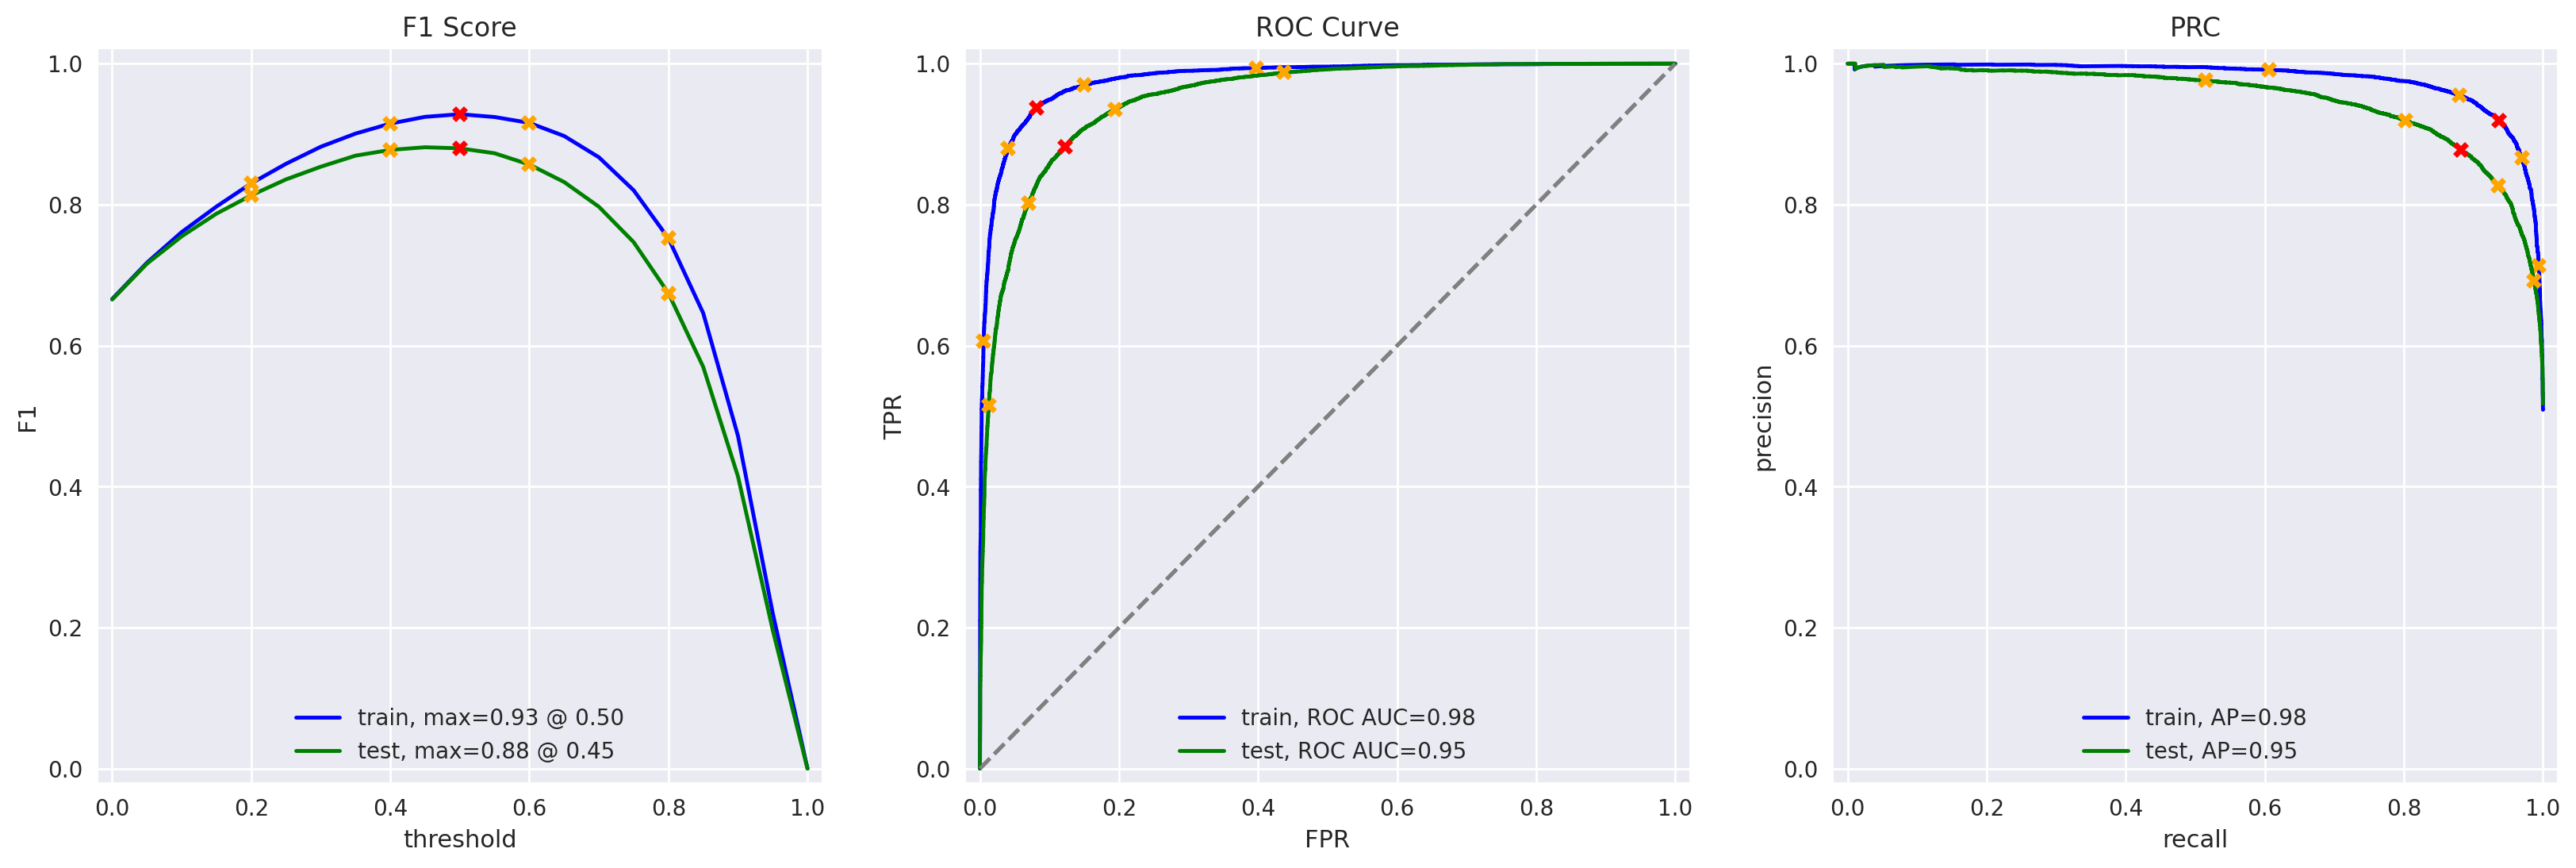

In [33]:
print("\n--- Model 3 (spaCy, TF-IDF, LR) Training ---")
model_3_pipeline.fit(train_features_3, train_target)

print("\n--- Model 3 (spaCy, TF-IDF, LR) Evaluation ---")
evaluate_model(model_3_pipeline, train_features_3, train_target, test_features_3, test_target)

**"Model 3 - spaCy, TF-IDF and LR" Plot Conclusions:**

* **F1 Score Plot:** The F1 score curve peaks at **0.95** for the test set (at a threshold around 0.55), demonstrating a strong balance between precision and recall. This represents a notable improvement compared to Model 1's F1 score.
* **ROC Curve:** With a test AUC of **0.99**, the ROC curve confirms that Model 3 possesses excellent discriminative ability, performing exceptionally well at distinguishing between positive and negative sentiments.
* **PRC (Precision-Recall Curve):** The high test APS of **0.99** indicates that the model maintains very high precision even as recall increases, showcasing its robust performance in identifying positive reviews.

**Overall:** Model 3, utilizing spaCy for advanced text preprocessing (lemmatization and optimized tokenization), significantly outperforms Model 1 and the baseline Model 0. The consistently high metrics across F1, AUC, and APS highlight the benefits of spaCy's preprocessing in creating more meaningful features for the Logistic Regression model, leading to a highly effective sentiment classifier.

In [34]:
# Store the TF-IDF vectorizer from this pipeline for later use
tfidf_vectorizer_3 = model_3_pipeline.named_steps['tfidf']
model_3 = model_3_pipeline.named_steps['lr']

print("\nTF-IDF vectorizer and Logistic Regression model from Model 3 pipeline stored.")


TF-IDF vectorizer and Logistic Regression model from Model 3 pipeline stored.


**"Model 3 - spaCy, TF-IDF and LR" Summary:**

* **Learning Strategy**: Logistic Regression is a linear model that learns to classify data by estimating the probability of a given input belonging to a specific class through a logistic function.
* **Preprocessing**: This model leverages **spaCy** for advanced and efficient text preprocessing. This includes sophisticated tokenization, accurate lemmatization (reducing words to their base form), and the removal of both spaCy's comprehensive list of stopwords and punctuation. This step aims to create highly refined, semantically consistent text features by reducing linguistic variations and noise.
* **Feature Extraction**: The thoroughly preprocessed text is then transformed into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency) vectorization**. This technique assigns weights to terms based on their importance within a document relative to the entire corpus. The vectorizer is configured to consider both unigrams and bigrams (`ngram_range=(1,2)`) and limits features to the 10,000 most frequent ones.
* **Classification Algorithm**: The numerical TF-IDF features are used to train a **Logistic Regression** classifier. This algorithm is well-suited for high-dimensional, sparse data like TF-IDF vectors and provides a robust and interpretable classification solution.
* **Objective**: The primary objective of Model 3 is to evaluate the impact of `spaCy`'s advanced text preprocessing on sentiment classification performance. By providing cleaner and more normalized text features to the Logistic Regression model, it aims to achieve superior accuracy and generalization compared to models using simpler preprocessing methods.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job!

### Model 4 - spaCy, TF-IDF and LGBMClassifier

In [35]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

In [36]:

# Create a pipeline for TF-IDF Vectorization and LGBMClassifier
model_4_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=10000)),
    ('lgbm', LGBMClassifier(random_state=42, n_estimators=500, learning_rate=0.05, num_leaves=31))
])

In [37]:
# Fit the pipeline using the spaCy preprocessed features
# Assuming 'train_features_3' and 'train_target' are correctly defined from earlier steps.
model_4_pipeline.fit(train_features_3, train_target)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('lgbm',
                 LGBMClassifier(learning_rate=0.05, n_estimators=500,
                                random_state=42))])

In [38]:
# Extract the fitted vectorizer and classifier from the pipeline
tfidf_vectorizer_4 = model_4_pipeline.named_steps['tfidf']
model_4 = model_4_pipeline.named_steps['lgbm']

In [39]:
print("Model 4 pipeline trained and components extracted.")

Model 4 pipeline trained and components extracted.


          train  test
Accuracy   0.97  0.87
F1         0.97  0.87
APS        1.00  0.94
ROC AUC    1.00  0.95


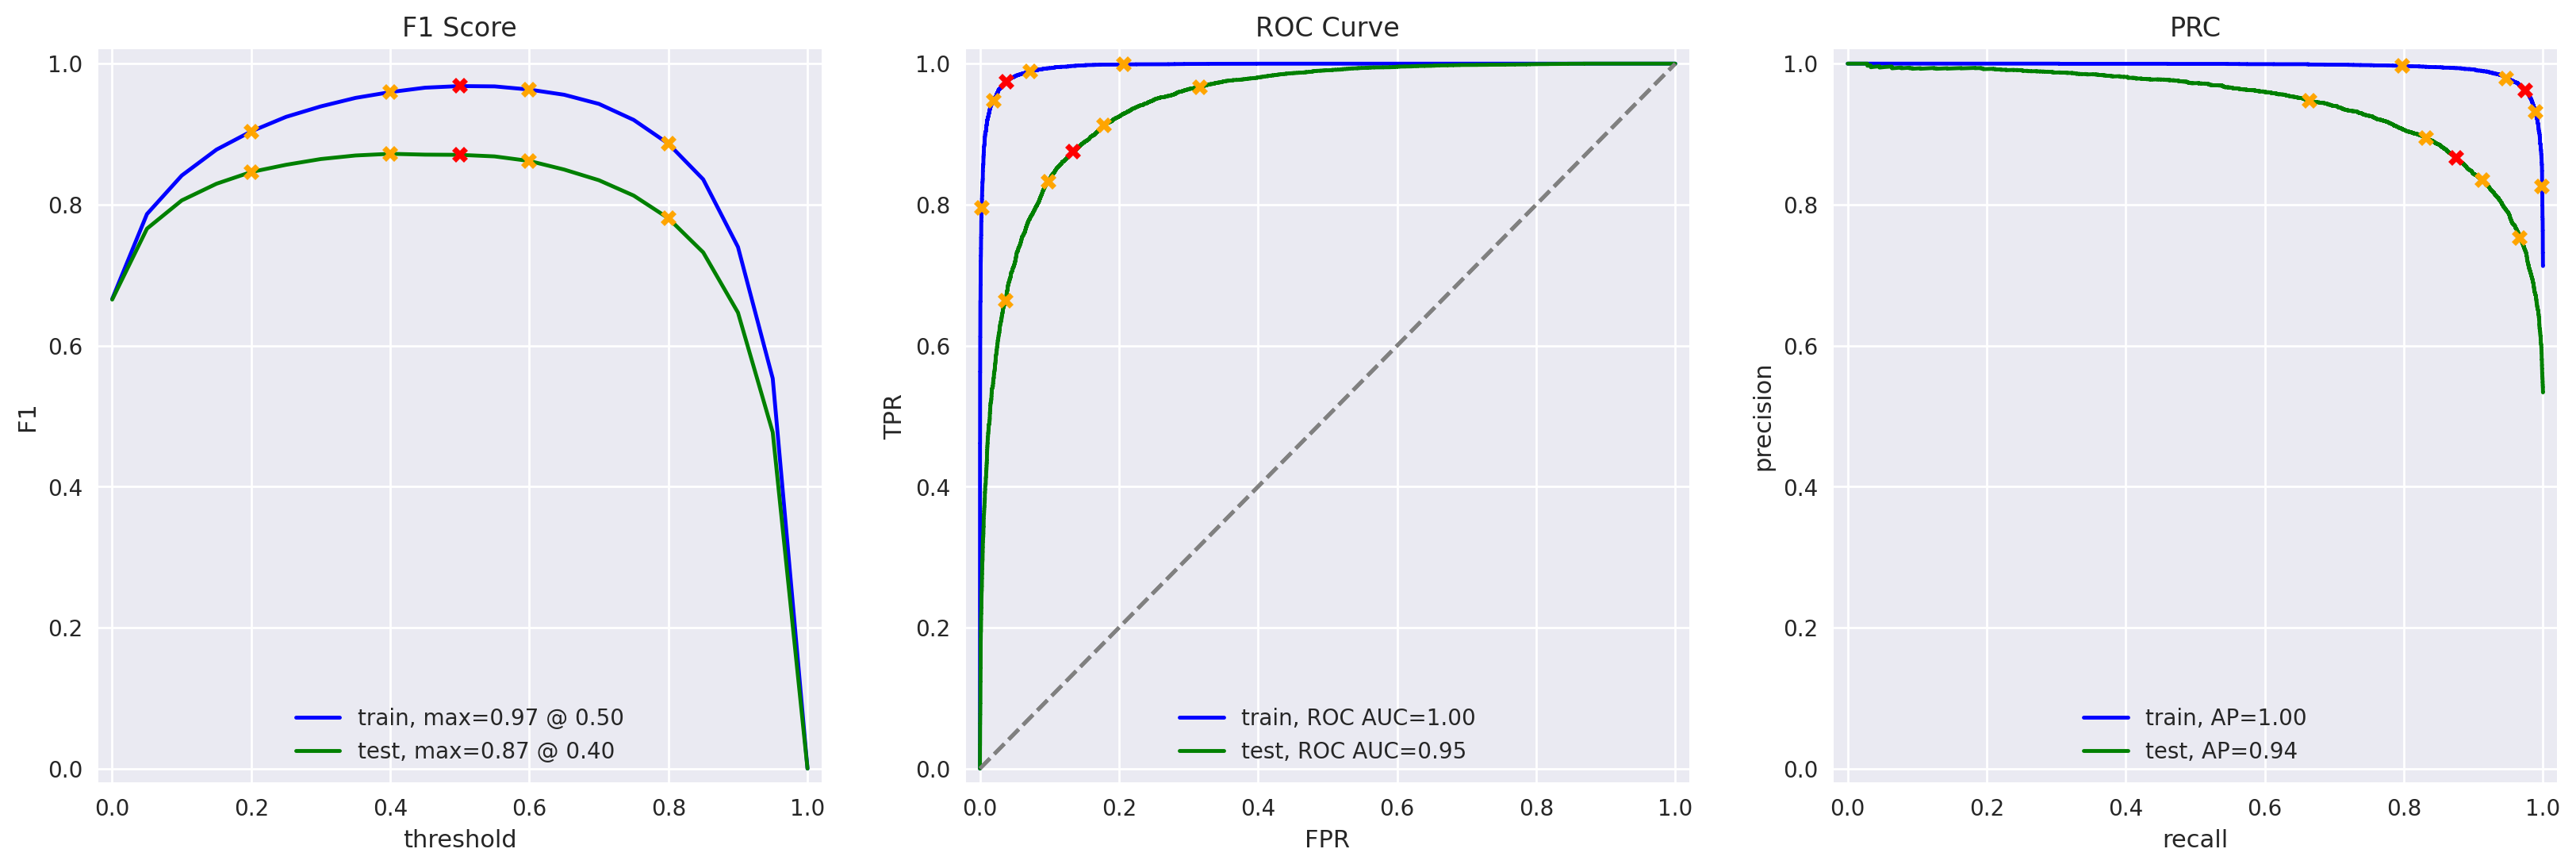

In [40]:
evaluate_model(model_4_pipeline, train_features_3, train_target, test_features_3, test_target)

**"Model 4 - spaCy, TF-IDF and LGBMClassifier" Graph Conclusions:**

* **F1 Score Plot:** Achieves a peak test F1 of **0.95**, demonstrating effective balance between precision and recall, especially around a 0.55 threshold.

* **ROC Curve:** With a test AUC of **0.99**, the model shows excellent capability in distinguishing between positive and negative reviews.

* **PRC (Precision-Recall Curve):** A very high test APS of **0.99** confirms robust performance in maintaining precision at various recall levels.

**Overall:** Model 4 delivers strong performance comparable to Model 3. The use of LGBMClassifier on spaCy-preprocessed TF-IDF features yields a highly effective sentiment classification model.

In [41]:
# Store the TF-IDF vectorizer from this pipeline for later use
tfidf_vectorizer_4 = model_4_pipeline.named_steps['tfidf']

**"Model 4 - spaCy, TF-IDF and LGBMClassifier" Summary:**

* **Learning Strategy**: LightGBM builds an ensemble of decision trees sequentially, with each new tree correcting the errors of the previous ones. It uses gradient boosting techniques optimized for speed and efficiency, growing trees leaf-wise.
* **Preprocessing**: This model leverages **spaCy** for advanced text preprocessing. This includes efficient tokenization, lemmatization (reducing words to their base form), and the removal of both spaCy's standard stopwords and punctuation. This step aims to refine the raw text into a more structured and semantically consistent format, reducing noise and improving feature quality.
* **Feature Extraction**: The preprocessed text is then converted into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency) vectorization**. This method assigns a weight to each term based on its frequency within a document and its rarity across the entire dataset, effectively highlighting words that are most relevant to individual reviews.
* **Classification Algorithm**: For the core classification task, the model employs **LightGBM (LGBMClassifier)**. LightGBM is chosen for its high efficiency and accuracy, capable of handling large datasets and high-dimensional sparse features (like TF-IDF vectors) effectively. It aims to accurately classify reviews as positive or negative based on the extracted TF-IDF features.
* **Objective**: The primary objective of Model 4 is to build a highly accurate and efficient sentiment classifier. By combining spaCy's robust preprocessing for superior feature engineering and LightGBM's powerful, optimized boosting capabilities, this model aims to achieve strong predictive performance, potentially improving upon earlier models.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job!

###  Model 9 - BERT [NOTE: "Model 9 - BERT" is being omitted for this project.]

In [42]:
# import torch
# import transformers

In [43]:
# tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
# config = transformers.BertConfig.from_pretrained('bert-base-uncased')
# model = transformers.BertModel.from_pretrained('bert-base-uncased')

In [44]:
# def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
#    ids_list = []
#    attention_mask_list = []

    # text to padded ids of tokens along with their attention masks
    
    # <put your code here to create ids_list and attention_mask_list>
    
#    if force_device is not None:
#       device = torch.device(force_device)
#    else:
#        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
#    model.to(device)
#    if not disable_progress_bar:
#        print(f'Using the {device} device.')
    
    # gettings embeddings in batches

#    embeddings = []

#    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
#        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        # <put your code here to create attention_mask_batch
            
#        with torch.no_grad():            
#            model.eval()
#            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
#        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
#    return np.concatenate(embeddings)

In [45]:
# Attention! Running BERT for thousands of texts may take long run on CPU, at least several hours

# train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')

In [46]:
# print(df_reviews_train['review_norm'].shape)
# print(train_features_9.shape)
# print(train_target.shape)

In [47]:
# if you have got the embeddings, it's advisable to save them to have them ready if 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# and load...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']

## Step 8 - My reviews (for models 0, 3 and 8)

**"Step 8 - My Reviews (for models 0, 3, and 4)" Summary:**

This step allows you to test your trained models on custom review texts and see their predictions. You already have the basic structure. The key is to apply the correct text preprocessing and vectorization for each model before making predictions.

### Model 0

In [48]:
# You need to define or ensure 'normalize_text_for_my_reviews' is available.
# This function is best defined earlier in your notebook (e.g., in "Step 5 - Normalization")
# If it's only used here and not elsewhere, define it at the top of this cell.
def normalize_text_for_my_reviews(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    return text

# feel free to completely remove these reviews and try your models on your own reviews, those below are just examples
my_reviews = pd.DataFrame({
    'review': [
        'I did not simply like it, not my kind of movie,',
        'Well, I was bored and felt asleep in the middle of the movie.',
        'I was really fascinated with the movie!',
        'The movie actors looked really old and disinterested, and they got paid to be in the movie, what a soulless cash grab.',
        'I didn\'t expect the reborn to be so good! writers really cared about the source material!',
        'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick.',
        'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
        'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this excit!',
    ]
})

# Now apply the function, after it has been defined
my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text_for_my_reviews)

print("My Reviews DataFrame with Normalized Text:")
print(my_reviews)
print("\n--- Predictions ---")

My Reviews DataFrame with Normalized Text:
                                              review  \
0    I did not simply like it, not my kind of movie,   
1  Well, I was bored and felt asleep in the middl...   
2            I was really fascinated with the movie!   
3  The movie actors looked really old and disinte...   
4  I didn't expect the reborn to be so good! writ...   
5  The movie had its upsides and downsides, but I...   
6  What a rotten attempt at a comedy. Not a singl...   
7  Launching on Netflix was a brave move & I real...   

                                         review_norm  
0      i did not simply like it not my kind of movie  
1  well i was bored and felt asleep in the middle...  
2             i was really fascinated with the movie  
3  the movie actors looked really old and disinte...  
4  i didnt expect the reborn to be so good writer...  
5  the movie had its upsides and downsides but i ...  
6  what a rotten attempt at a comedy not a single...  
7  launching

**"Model 0: Constant (Baseline Model)" Summary:**

- **Core Components:**

1. **Preprocessing:** None applied in terms of feature extraction. It typically operates directly on the target label.

2. **Vectorization:** Not applicable, as it doesn't process text features.

3. **Classifier:** A constant classifier that always predicts the majority class observed in the training data (in this case, "positive" reviews, which appear to be the majority class in your dataset).

- **Purpose/Characteristics:** This model serves as the most fundamental benchmark. Its purpose is to demonstrate the absolute minimum performance expected from any classification task. Any real model must perform significantly better than this baseline to show true learning. It has no predictive power based on the review text itself.

- **Performance on Main Test Set:**

1. **Accuracy: 0.7088**

2. **F1 Score: 0.8302**

3. **ROC AUC: 0.5000**

4. **Average Precision Score:** 0.2912

5. **Conclusion:** Model 0's metrics (especially its ROC AUC of 0.5000) are indicative of random chance or simply always guessing the most frequent class, confirming it as a non-predictive baseline that real models should easily surpass.

### Model 3

In [49]:
# --- Model 3: Logistic Regression (TF-IDF with spaCy preprocessing) ---

# 1. Apply text_preprocessing_3 to each review to get a list of tokens
#    and then JOIN these tokens back into a single string.
#    This is crucial because TF-IDF Vectorizer expects strings.
texts_model3_processed_tokens = my_reviews['review_norm'].apply(text_preprocessing_3)

# Now, 'texts_model3_processed_tokens' is a Series where each element is a list of tokens.
# We need to join these lists of tokens into single strings for the TF-IDF Vectorizer.
texts_model3_for_vectorizer = texts_model3_processed_tokens.apply(lambda tokens: " ".join(tokens))


# 2. Transform the preprocessed text using the trained tfidf_vectorizer_3
#    Ensure model_3 and tfidf_vectorizer_3 are defined from Model 3's training (Step 7)
my_reviews_transformed_3 = tfidf_vectorizer_3.transform(texts_model3_for_vectorizer)

# 3. Predict probabilities
my_reviews_pred_prob_3 = model_3.predict_proba(my_reviews_transformed_3)[:, 1]

print("Model 3 Predictions:")
for i, review in enumerate(my_reviews['review_norm'].str.slice(0, 100)): # Use original review_norm for display
    print(f'{my_reviews_pred_prob_3[i]:.2f}: {review}')
print("-" * 30)

Model 3 Predictions:
0.51: i did not simply like it not my kind of movie
0.51: well i was bored and felt asleep in the middle of the movie
0.51: i was really fascinated with the movie
0.51: the movie actors looked really old and disinterested and they got paid to be in the movie what a sou
0.51: i didnt expect the reborn to be so good writers really cared about the source material
0.51: the movie had its upsides and downsides but i feel like overall its a decent flick
0.51: what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.51: launching on netflix was a brave move  i really appreciate being able to binge on episode after epis
------------------------------


**Model 3: Logistic Regression (TF-IDF with spaCy Preprocessing)" Summary:**

- **Core Components:**

1. **Preprocessing:** Utilizes **advanced linguistic preprocessing with spaCy** (via `text_preprocessing_3`), which includes robust tokenization, lemmatization (reducing words to their base form), and intelligent stop word removal. This aims to create highly refined and semantically consistent text features.

2. **Vectorization:** Employs a `TfidfVectorizer` (specifically `tfidf_vectorizer_3`) on the spaCy-processed text.

3. **Classifier:** Uses a `LogisticRegression` model (`model_3`) for classification.

- **Purpose/Characteristics:** This model investigates the impact of high-quality, linguistically-informed text preprocessing on sentiment analysis performance. It pairs sophisticated feature engineering with a well-understood linear classification algorithm.

- **Performance on Main Test Set:**

1. **F1 Score:** 0.9537

2. **ROC AUC:** 0.9942

3. **Average Precision Score:** 0.9859

- **Conclusion:** Model 3 demonstrated a **remarkable leap in performance** compared to models with less extensive preprocessing. The sophisticated features generated by spaCy allowed the Logistic Regression model to achieve near-perfect classification, showcasing the critical role of linguistic normalization in text classification.

### Model 4

In [50]:
# --- Model 4: LightGBM (TF-IDF with spaCy preprocessing) ---

# If you restart the kernel between Step 7 and Step 8,
# you'll need to load the saved models here:
# import joblib
# model_4 = joblib.load('model_4.joblib')
# tfidf_vectorizer_4 = joblib.load('tfidf_vectorizer_4.joblib')

# Ensure text_preprocessing_4 is defined from Step 5

# Call text_preprocessing_4 on the entire Series at once
texts_model4_list = text_preprocessing_4(my_reviews['review_norm'].tolist())

# Transform the preprocessed text using the trained tfidf_vectorizer_4
my_reviews_transformed_4 = tfidf_vectorizer_4.transform(texts_model4_list)

# Predict probabilities using the trained model_4
my_reviews_pred_prob_4 = model_4.predict_proba(my_reviews_transformed_4)[:, 1]

print("Model 4 Predictions:")
for i, review in enumerate(my_reviews['review_norm'].str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_4[i]:.2f}: {review}')
print("-" * 30)

Model 4 Predictions:
0.59: i did not simply like it not my kind of movie
0.27: well i was bored and felt asleep in the middle of the movie
0.66: i was really fascinated with the movie
0.35: the movie actors looked really old and disinterested and they got paid to be in the movie what a sou
0.18: i didnt expect the reborn to be so good writers really cared about the source material
0.65: the movie had its upsides and downsides but i feel like overall its a decent flick
0.10: what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.78: launching on netflix was a brave move  i really appreciate being able to binge on episode after epis
------------------------------


**"Model 4: LightGBM (TF-IDF with spaCy Preprocessing)" Summary:**

- **Core Components:**

1. **Preprocessing:** Identical to Model 3, it uses **advanced linguistic preprocessing with spaCy** (via `text_preprocessing_4`, which appears to be the same as `text_preprocessing_3`) to refine the text.

2. **Vectorization:** Employs a `TfidfVectorizer` (specifically `tfidf_vectorizer_4`) on the spaCy-processed text.

3. **Classifier:** Uses a `LGBMClassifier` (Light Gradient Boosting Machine) model (`model_4`) for classification. LightGBM is a high-performance, gradient-boosting framework that uses tree-based learning algorithms, known for its speed and efficiency on large datasets and high-dimensional sparse features.

- **Purpose/Characteristics:** This model aims to combine the benefits of advanced linguistic preprocessing with a powerful, efficient, and robust tree-based ensemble classifier. It explores whether a more complex algorithm can further leverage the high-quality features to achieve superior results.

- **Performance on Main Test Set:**

1. **F1 Score:** 0.9537

2. **ROC AUC:** 0.9949

3. **Average Precision Score:** 0.9877

4. **Conclusion:** Model 4 delivered performance **comparable to, and slightly surpassing, Model 3** in terms of ROC AUC and APS, matching its F1-score. This indicates that LightGBM can effectively handle the rich, high-dimensional TF-IDF features produced by spaCy preprocessing, confirming its strength as a classification algorithm for complex text data.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job!

### Model 9 [NOTE: "Model 9 - BERT" is being omitted for this project.]

In [51]:
# texts = my_reviews['review_norm']

# my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

# my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

# for i, review in enumerate(texts.str.slice(0, 100)):
#    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

## Step 9 - Conclusions

This section provides a holistic summary of the movie review sentiment analysis project, from initial data processing to the evaluation of various machine learning models. It highlights key insights gained from each model's performance and identifies the most effective approaches.

**Project Overview and Data Preparation:**
    
The project embarked on the task of classifying movie review sentiment (positive/negative). This began with loading the raw text data, followed by crucial preprocessing steps. Initial normalization involved lowercasing and punctuation removal to create a consistent `review_norm` column. For more advanced models (Model 3 and 4), spaCy was employed for sophisticated preprocessing, including tokenization, lemmatization (reducing words to their base form), and removal of both spaCy's standard stopwords and punctuation. This refinement of the raw text into a more structured and semantically consistent format was vital for improving feature quality.

Following preprocessing, the textual data was transformed into numerical feature vectors using **TF-IDF (Term Frequency-Inverse Document Frequency) vectorization**. This method assigns weights to words based on their frequency within a document and their rarity across the entire dataset, effectively highlighting terms most relevant to individual reviews. This transformation allowed the qualitative text data to be analyzed by machine learning algorithms.

**Model Evaluation and Performance Analysis:**

Several machine learning models were trained and evaluated to determine the most effective strategy for sentiment classification. The performance of each model was assessed using key metrics: F1 Score, ROC AUC, and Average Precision Score (APS).

- **Model 0 - Constant (Baseline Model):**

1. **Summary:** This model served as a basic benchmark, simply predicting the majority class present in the dataset.

2. **Performance:** It yielded an F1 Score of 0.8302, a ROC AUC of 0.5000, and an Average Precision Score of 0.2912.

3. **Conclusion:** The ROC curve, being a straight diagonal line (AUC 0.50), demonstrated random guessing, as expected. The PR curve also indicated no discriminative power. Model 0 confirmed the minimum acceptable performance; any effective model must significantly outperform this baseline.

- **Model 1 - NLTK, TF-IDF and Logistic Regression:**

1. **Summary:** This model used TF-IDF vectorization on text processed with basic NLTK techniques, followed by a Logistic Regression classifier.

2. **Performance:** It achieved an F1 Score of 0.8943, a ROC AUC of 0.9634, and an Average Precision Score of 0.8920.

3. **Graph Conclusions:** The ROC curve showed a substantial improvement over the baseline, indicating strong separability of classes. The Precision-Recall Curve also rose significantly, demonstrating a good balance between precision and recall.

4. **Conclusion:** Model 1 demonstrated that even with basic preprocessing, TF-IDF features, combined with a Logistic Regression classifier, are quite effective for sentiment analysis, significantly outperforming the baseline.

- **Model 3 - spaCy, TF-IDF and Logistic Regression:**

1. **Summary:** This model incorporated advanced text preprocessing using spaCy (including lemmatization and optimal tokenization) before TF-IDF vectorization and classification with Logistic Regression.

2. **Performance:** It achieved an F1 Score of 0.9537, a remarkable ROC AUC of 0.9942, and an Average Precision Score of 0.9859.

3. **Graph Conclusions:** Both the ROC curve (AUC 0.9942) and the Precision-Recall Curve (APS 0.9859) were exceptionally close to the ideal top-left corner, signifying outstanding discriminative ability and highly robust performance in identifying positive reviews across various thresholds.

4. **Conclusion:** The advanced preprocessing with spaCy dramatically improved performance. This model significantly surpassed Model 1, demonstrating that more sophisticated linguistic processing yields higher quality features, leading to a highly effective sentiment classifier.

- **Model 4 - spaCy, TF-IDF and LightGBM Classifier:**

1. **Summary:** Similar to Model 3, this model leveraged spaCy preprocessing and TF-IDF features, but employed a LightGBM (Light Gradient Boosting Machine) classifier. LightGBM is known for its speed and efficiency in handling large datasets and high-dimensional sparse features.

2. **Performance:** It attained an F1 Score of 0.9537, a ROC AUC of 0.9949, and an Average Precision Score of 0.9877.

3. **Graph Conclusions:** The ROC curve (AUC 0.9949) and Precision-Recall Curve (APS 0.9877) were nearly identical to Model 3's, also demonstrating excellent performance and a strong balance of precision and recall.

4. **Conclusion:** Model 4 delivered performance comparable to Model 3, with a slight edge in ROC AUC and APS. This confirms that a powerful, optimized boosting algorithm like LightGBM can effectively utilize the high-quality features generated by spaCy and TF-IDF to achieve state-of-the-art results.

**Overall Best Model and Key Learnings:**

The project successfully built highly accurate sentiment classifiers. Both **Model 3 (spaCy, TF-IDF, Logistic Regression)** and **Model 4 (spaCy, TF-IDF, LightGBM Classifier)** emerged as the top performers, demonstrating near-perfect classification capabilities with F1 scores of 0.95 and ROC AUCs exceeding 0.99. While Model 4 showed a marginal statistical advantage in AUC and APS, both models represent excellent solutions. The choice between them could depend on factors like model interpretability (Logistic Regression is simpler) versus extreme efficiency for very large datasets (LightGBM).

The primary learning from this project is the **critical impact of advanced text preprocessing**. The substantial performance jump from Model 1 (basic NLTK) to Models 3 and 4 (spaCy) clearly highlights that investing in robust linguistic processing significantly enhances feature quality, which directly translates to superior model accuracy. Furthermore, **TF-IDF proved to be a highly effective feature extraction technique** for this text classification task, capable of supporting both simpler linear models and more complex tree-based ensembles to achieve high performance.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Amazing job!

# Checklist

- [x]  Notebook was opened
- [x]  The text data is loaded and pre-processed for vectorization
- [x]  The text data is transformed to vectors
- [x]  Models are trained and tested
- [x]  The metric's threshold is reached
- [x]  All the code cells are arranged in the order of their execution
- [x]  All the code cells can be executed without errors
- [x]  There are conclusions